In [397]:
import numpy
import matplotlib.pyplot as plt
import math 

In [398]:
lambd = 2.8 / 100
b = 13 / 100
a = 13 / 100

In [399]:
F1h = [1]
FC = [1]
FH = [1]
steps = [0]
SGP1 = 0
fS1 = 0
Zeros = []
max_x_FH = []
max_y_FH = []
min_x_FH = []
min_y_FH = []

In [400]:
for teta in numpy.arange(0.01, numpy.pi / 2, 0.00001):
    mn1 = abs((1 + numpy.cos(teta)) / 2)
    mn2 = abs(math.sin((numpy.pi * b * math.sin(teta)) / lambd)/(numpy.pi * b * math.sin(teta) / lambd))
    mn3 = mn1 * mn2
    F1h.append(mn1)
    FC.append(mn2)
    FH.append(mn3)
    if 0.707 < mn3 < 0.708:
        SGP1 = 2 * math.degrees(teta)
        fS1 = mn3
    steps.append(math.degrees(teta))

for i in range(1, len(FH) - 1):
    if FH[i] > FH[i - 1] and FH[i] > FH[i + 1]:
        max_x_FH.append(steps[i])
        max_y_FH.append(FH[i])

for i in range(1, len(FH) - 1):
    if FH[i] < FH[i - 1] and FH[i] < FH[i + 1]:
        min_x_FH.append(steps[i])
        min_y_FH.append(0)

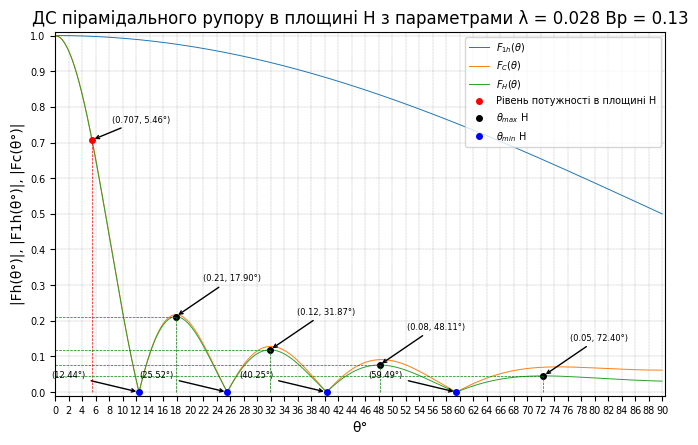

In [401]:
fig, ax = plt.subplots(figsize=(20/2.54, 12/2.54))
plt.title(f"ДС пірамідального рупору в площині H з параметрами λ = {round(lambd, 4)} Bp = {round(b, 4)}")
ax.plot(steps, F1h, linewidth=0.7, label="$ F_{1h}(θ) $")
ax.plot(steps, FC, linewidth=0.7, label="$ F_{C}(θ) $")
ax.plot(steps, FH, linewidth=0.7, label="$ F_{H}(θ) $")
ax.plot(SGP1/2, fS1, 'ro', markersize=4, label="Рівень потужності в площині H")

plt.annotate(f'({fS1:.3f}, {SGP1/2:.2f}\u00b0)',
                 xy=(SGP1 / 2, fS1),
                 xytext=((SGP1/2)+3, fS1+0.05),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)

ax.plot([SGP1/2, SGP1/2], [0, fS1], 'r--', linewidth=0.5)
ax.plot(max_x_FH, max_y_FH, "o", markersize=4, color="black", label="$ \\theta_{max} $ H")
ax.plot(min_x_FH, min_y_FH, "o", markersize=4, color="blue", label="$ \\theta_{min} $ H")

ax.set_xlabel('θ' + '\u00b0', fontsize=10)
ax.set_ylabel('|Fh(θ' + '\u00b0' + ')|, |F1h(θ' + '\u00b0' + ')|, |Fc(θ' + '\u00b0' + ')|', fontsize=10)
plt.xticks(numpy.arange(0, 100, 2), fontsize=7)
plt.yticks(numpy.arange(0, 1.2, 0.1), fontsize=7)
plt.ylim(-0.01, 1.01)
plt.xlim(0, 90.5)


for i in range(len(max_x_FH)):
    plt.vlines(x=max_x_FH[i], ymin=0, ymax=max_y_FH[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.hlines(y=max_y_FH[i], xmin=0, xmax=max_x_FH[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.annotate(f'({max_y_FH[i]:.2f}, {max_x_FH[i]:.2f}\u00b0)',
                 xy=(max_x_FH[i], max_y_FH[i]),
                 xytext=(max_x_FH[i]+4, max_y_FH[i]+0.1),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)
for i in range(len(min_x_FH)):
    plt.annotate(f'({min_x_FH[i]:.2f}\u00b0)',
                 xy=(min_x_FH[i], min_y_FH[i]),
                 xytext=(min_x_FH[i]-13, min_y_FH[i]+0.04),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)

plt.legend(loc="upper right", fontsize=7)
plt.grid(which='both', linestyle='--', linewidth=0.2, color='gray')

fig.savefig("ДС у площині Н, лабораторна 3.jpg", dpi=600)
plt.show()

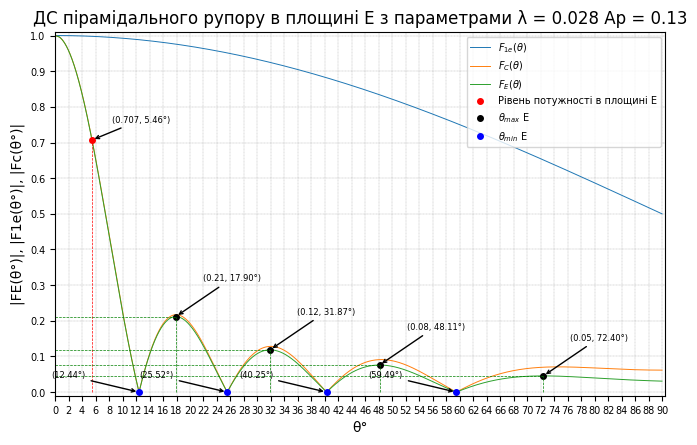

In [402]:
fig, ax = plt.subplots(figsize=(20/2.54, 12/2.54))
plt.title(f"ДС пірамідального рупору в площині E з параметрами λ = {round(lambd, 4)} Ap = {round(a, 4)}")
ax.plot(steps, F1h, linewidth=0.7, label="$ F_{1e}(θ) $")
ax.plot(steps, FC, linewidth=0.7, label="$ F_{C}(θ) $")
ax.plot(steps, FH, linewidth=0.7, label="$ F_{E}(θ) $")
ax.plot(SGP1/2, fS1, 'ro', markersize=4, label="Рівень потужності в площині E")

plt.annotate(f'({fS1:.3f}, {SGP1/2:.2f}\u00b0)',
                 xy=(SGP1 / 2, fS1),
                 xytext=((SGP1/2)+3, fS1+0.05),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)

ax.plot([SGP1/2, SGP1/2], [0, fS1], 'r--', linewidth=0.5)
ax.plot(max_x_FH, max_y_FH, "o", markersize=4, color="black", label="$ \\theta_{max} $ E")
ax.plot(min_x_FH, min_y_FH, "o", markersize=4, color="blue", label="$ \\theta_{min} $ E")

ax.set_xlabel('θ' + '\u00b0', fontsize=10)
ax.set_ylabel('|FE(θ' + '\u00b0' + ')|, |F1e(θ' + '\u00b0' + ')|, |Fc(θ' + '\u00b0' + ')|', fontsize=10)
plt.xticks(numpy.arange(0, 100, 2), fontsize=7)
plt.yticks(numpy.arange(0, 1.2, 0.1), fontsize=7)
plt.ylim(-0.01, 1.01)
plt.xlim(0, 90.5)


for i in range(len(max_x_FH)):
    plt.vlines(x=max_x_FH[i], ymin=0, ymax=max_y_FH[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.hlines(y=max_y_FH[i], xmin=0, xmax=max_x_FH[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.annotate(f'({max_y_FH[i]:.2f}, {max_x_FH[i]:.2f}\u00b0)',
                 xy=(max_x_FH[i], max_y_FH[i]),
                 xytext=(max_x_FH[i]+4, max_y_FH[i]+0.1),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)
for i in range(len(min_x_FH)):
    plt.annotate(f'({min_x_FH[i]:.2f}\u00b0)',
                 xy=(min_x_FH[i], min_y_FH[i]),
                 xytext=(min_x_FH[i]-13, min_y_FH[i]+0.04),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)

plt.legend(loc="upper right", fontsize=7)
plt.grid(which='both', linestyle='--', linewidth=0.2, color='gray')

fig.savefig("ДС у площині Е, лабораторна 3.jpg", dpi=600)
plt.show()

In [403]:
print("Варіант = 4")
print(f"Довжина хвилі = {round(lambd, 4)} (м)")
print(f"Розмір розкриву рупора а*b = {round(a, 4)} X {round(b, 4)} (м)")

Варіант = 4
Довжина хвилі = 0.028 (м)
Розмір розкриву рупора а*b = 0.13 X 0.13 (м)


In [404]:

print("Табл. 1 - Значення нульових кутів")
print("-----------------")
print("| № |  θ  |FE(θ)|")
m = 1
for i in min_x_FH:
    print(f"| {m} |{i:.2f}|  {0}  |")
    m += 1
print("-----------------")

print("Табл. 2 - Значення максимальних кутів")
print("-----------------")
print("| № |  θ  |FE(θ)|")
m = 1
for i in max_x_FH:
    print(f"| {m} |{i:.2f}| {max_y_FH[m-1]:.2f}|")
    m += 1
print("-----------------")

Табл. 1 - Значення нульових кутів
-----------------
| № |  θ  |FE(θ)|
| 1 |12.44|  0  |
| 2 |25.52|  0  |
| 3 |40.25|  0  |
| 4 |59.49|  0  |
-----------------
Табл. 2 - Значення максимальних кутів
-----------------
| № |  θ  |FE(θ)|
| 1 |17.90| 0.21|
| 2 |31.87| 0.12|
| 3 |48.11| 0.08|
| 4 |72.40| 0.05|
-----------------


In [405]:
print("Ширина головної пелюстки = " + str(round(SGP1, 2)) + '\u00b0')

Ширина головної пелюстки = 10.92°
